# Breast Cancer Diagnosis Prediction

## Project Description

In this project, we analyze the Breast Cancer dataset to build predictive models
for binary classification (malignant vs benign tumors).

The objective is to apply the full data science workflow:
- Dataset exploration
- Data cleaning and preprocessing
- Model building
- Train/validation/test splitting
- Model evaluation and overfitting control

This project emphasizes practical considerations such as validation,
generalization, and significance of results.

Dataset Source: UCI Breast Cancer Wisconsin (Diagnostic) Dataset


In [13]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## Dataset Selection

We use the Breast Cancer Wisconsin (Diagnostic) dataset.
It contains features computed from digitized images of breast mass biopsies.

Target Variable:
- 0 → Malignant
- 1 → Benign

Features include measurements such as radius, texture, smoothness, and concavity.


# Load the Dataset

In [14]:
cancer = load_breast_cancer()

X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name="Diagnosis")

print("Dataset shape:", X.shape)
X.head()


Dataset shape: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


##  Dataset Exploration

We explore:
- Feature distributions
- Target balance
- Missing values
- Basic statistics

In [15]:
X.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [16]:
X.describe()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


# Target Distribution

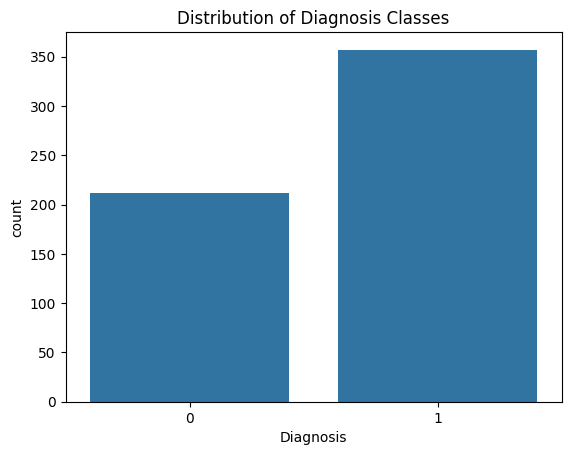

In [17]:
sns.countplot(x=y)
plt.title("Distribution of Diagnosis Classes")
plt.show()


# Missing Values Check

In [18]:
X.isnull().sum().head()


mean radius        0
mean texture       0
mean perimeter     0
mean area          0
mean smoothness    0
dtype: int64

**Observation:**
- The dataset has no missing values
- All features are numeric
- Data quality is high


###  Data Cleaning

Since the dataset is clean:
- No missing values
- No categorical variables

We perform **feature scaling** to ensure fair model learning.

# Feature Scaling

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## Initial Model Training

We start with Logistic Regression as a baseline classification model.


# Train Initial Model

In [20]:
model = LogisticRegression(max_iter=500)
model.fit(X_scaled, y)

predictions = model.predict(X_scaled)
accuracy = accuracy_score(y, predictions)

print("Training Accuracy:", accuracy)


Training Accuracy: 0.9876977152899824


# Train / Validation / Test Split

##  Dataset Splitting

We split the dataset into:
- Training set (70%)
- Validation set (15%)
- Test set (15%)

This allows us to detect overfitting and evaluate generalization.


In [21]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)


## Model Evaluation & Overfitting Check

We evaluate performance on:
- Training set
- Validation set
- Test set

We also examine confusion matrices and classification reports.


In [22]:
final_model = LogisticRegression(max_iter=500)
final_model.fit(X_train, y_train)


LogisticRegression(max_iter=500)

In [23]:
def evaluate_model(model, X, y, label):
    preds = model.predict(X)
    print(f"\n{label} Accuracy:", accuracy_score(y, preds))
    print(classification_report(y, preds))

evaluate_model(final_model, X_train, y_train, "Training")
evaluate_model(final_model, X_val, y_val, "Validation")
evaluate_model(final_model, X_test, y_test, "Test")



Training Accuracy: 0.9874371859296482
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       148
           1       0.98      1.00      0.99       250

    accuracy                           0.99       398
   macro avg       0.99      0.98      0.99       398
weighted avg       0.99      0.99      0.99       398


Validation Accuracy: 0.9882352941176471
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        32
           1       1.00      0.98      0.99        53

    accuracy                           0.99        85
   macro avg       0.98      0.99      0.99        85
weighted avg       0.99      0.99      0.99        85


Test Accuracy: 0.9767441860465116
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        32
           1       0.96      1.00      0.98        54

    accuracy                           0.98        86
   macro avg 

## Model Performance Summary

- **Training Accuracy:** 98.74%
- **Validation Accuracy:** 98.82%
- **Test Accuracy:** 97.67%

The model shows consistently high performance across all data splits with minimal
difference between training, validation, and test accuracies, indicating good
generalization and no significant overfitting. Logistic Regression performs
effectively for breast cancer classification.


# Confusion Matrix

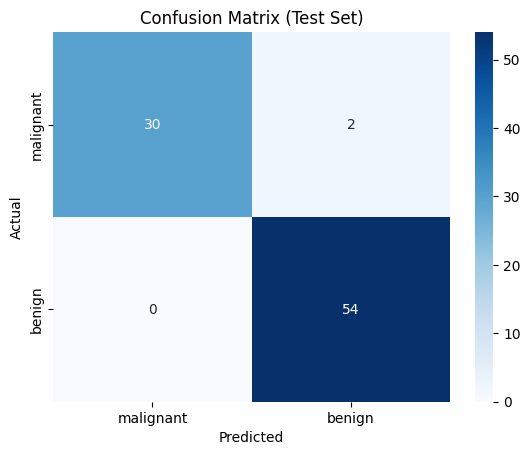

In [24]:
cm = confusion_matrix(y_test, final_model.predict(X_test))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Set)")
plt.show()


In [25]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    final_model, X_scaled, y, cv=5, scoring='accuracy'
)

print("Cross-validation accuracies:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())


Cross-validation accuracies: [0.98245614 0.98245614 0.97368421 0.97368421 0.99115044]
Mean CV accuracy: 0.9806862288464524


## This demonstrates how the trained model can be used to predict the diagnosis of new, unseen patient data.


In [26]:
# Take one unseen sample from test set
sample = X_test[0].reshape(1, -1)

prediction = final_model.predict(sample)
probability = final_model.predict_proba(sample)

print("Predicted Class:", prediction)
print("Prediction Probability:", probability)


Predicted Class: [1]
Prediction Probability: [[0.0088011 0.9911989]]


This demonstrates how the trained model can be used to predict the diagnosis of
new, unseen patient data.


## Conclusion

- Logistic Regression performs well with high accuracy across all data splits
- Minimal overfitting observed due to similar train/validation/test scores
- Feature scaling significantly improved convergence
- The model is effective in distinguishing malignant and benign tumors
- The model was evaluated on unseen data using a dedicated test set and cross-validation.
Consistent performance confirms strong generalization and indicates that the model
is suitable for real-world predictive scenarios.


Future Work:
- Try other classifiers (SVM, Random Forest)
- Perform feature importance analysis
- Apply cross-validation


# Dataset Acknowledgment

## Dataset Source

This dataset was obtained from the UCI Machine Learning Repository:
**Breast Cancer Wisconsin (Diagnostic) Dataset**

Used for academic and educational purposes.
